In [23]:
import matplotlib.pyplot as plt
import numpy as np

import pymc as pm
import pytensor.tensor as pt
import pytensor
from tqdm.notebook import tqdm
pytensor.config.cxx = '/usr/bin/clang++'

from modulars import plot_a_few_trajectories_1d, plot_mean_band_rrs_1d
from modulars import load_config, load_best_values
from modulars import exp_lognormal_moments
from modulars import gaussian_1d
from modulars import run_pymc_VI, run_single_seed_pymc_VI
transform_fn = exp_lognormal_moments


In [24]:
config_file = '../invgamma_config.json'
config = load_config(config_file)
mu_like = config['mu_like']
sigma_like = config['sigma_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']
max_iters = 100_000#config['max_iters']

DATA = True
if DATA:
  data = gaussian_1d(n_samples, mu_like, sigma_like=sigma_like).astype(np.float32)
else:
  data = []

In [25]:
def run_model(n_mc_samples = 1, optimizer = 'default', seed = 0):
    with pm.Model() as model:
        # Prior
        sigmasq = pm.InverseGamma('sigmasq', alpha=alpha_prior, beta=beta_prior)

        # Likelihood
        like = pm.Normal('like', mu_like, pt.sqrt(sigmasq), observed=data)

        # run my pymc wrapper that allows for random restarts 
        # and tracking values across MC samples and optimizers
        tracked_vals = run_pymc_VI(model, n_mc_samples, max_iters, optimizer, seed)
    return tracked_vals

In [26]:
results = []
results_adam = []
for seed in tqdm(range(5)):
    all_results = run_single_seed_pymc_VI(seed, run_model)
    results.append(all_results[0])
    results_adam.append(all_results[1])

  0%|          | 0/5 [00:00<?, ?it/s]

Finished [100%]: Average Loss = 9.0648
Finished [100%]: Average Loss = 9.0635
Finished [100%]: Average Loss = 9.0591
Finished [100%]: Average Loss = 9.0636
Finished [100%]: Average Loss = 9.0881
Finished [100%]: Average Loss = 9.0632
Finished [100%]: Average Loss = 9.0692
Finished [100%]: Average Loss = 9.0632
Finished [100%]: Average Loss = 9.074
Finished [100%]: Average Loss = 9.0626
Finished [100%]: Average Loss = 9.0653
Finished [100%]: Average Loss = 9.0627
Finished [100%]: Average Loss = 9.0867
Finished [100%]: Average Loss = 9.0625
Finished [100%]: Average Loss = 9.063
Finished [100%]: Average Loss = 9.0626
Finished [100%]: Average Loss = 9.0636
Finished [100%]: Average Loss = 9.0629
Finished [100%]: Average Loss = 9.0576
Finished [100%]: Average Loss = 9.063


In [ ]:
from modulars import apply_traj_transform
single_means, single_stds, multi_means, multi_stds = \
    apply_traj_transform(results, transform_fn, n_samples=10_000, seed=1, NOTEBOOK=True)

single_means_adam, single_stds_adam, multi_means_adam, multi_stds_adam = \
    apply_traj_transform(results_adam, transform_fn, n_samples=10_000, seed=1, NOTEBOOK=True)

N, T = single_means.shape
x = np.arange(T)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

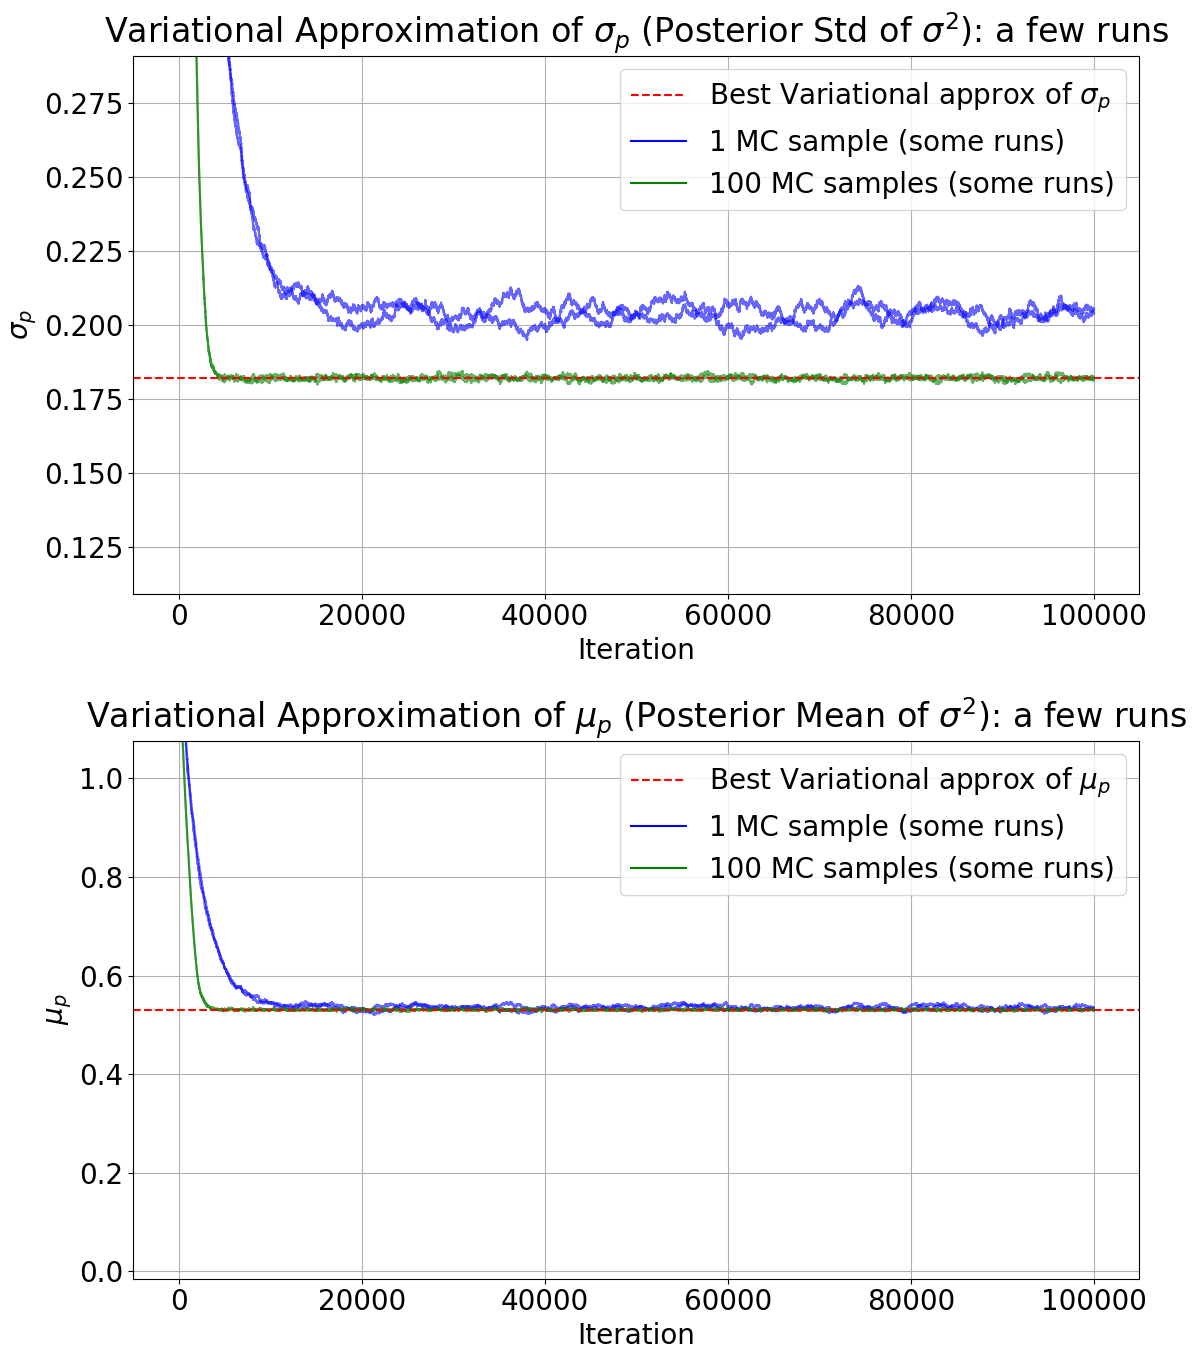

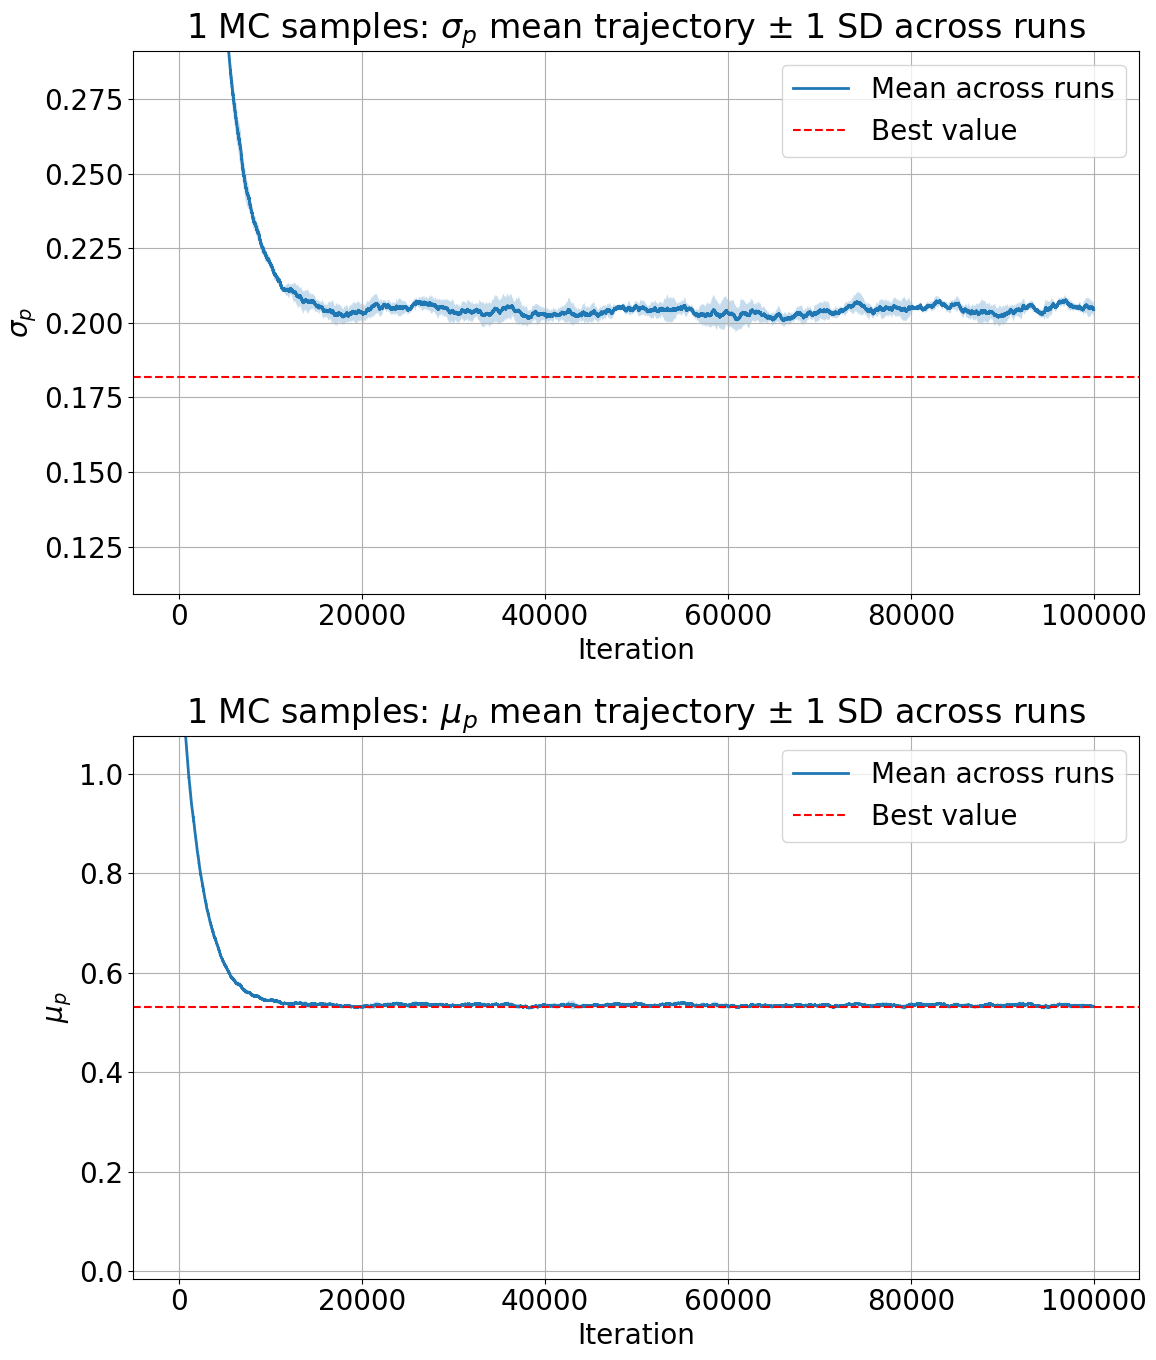

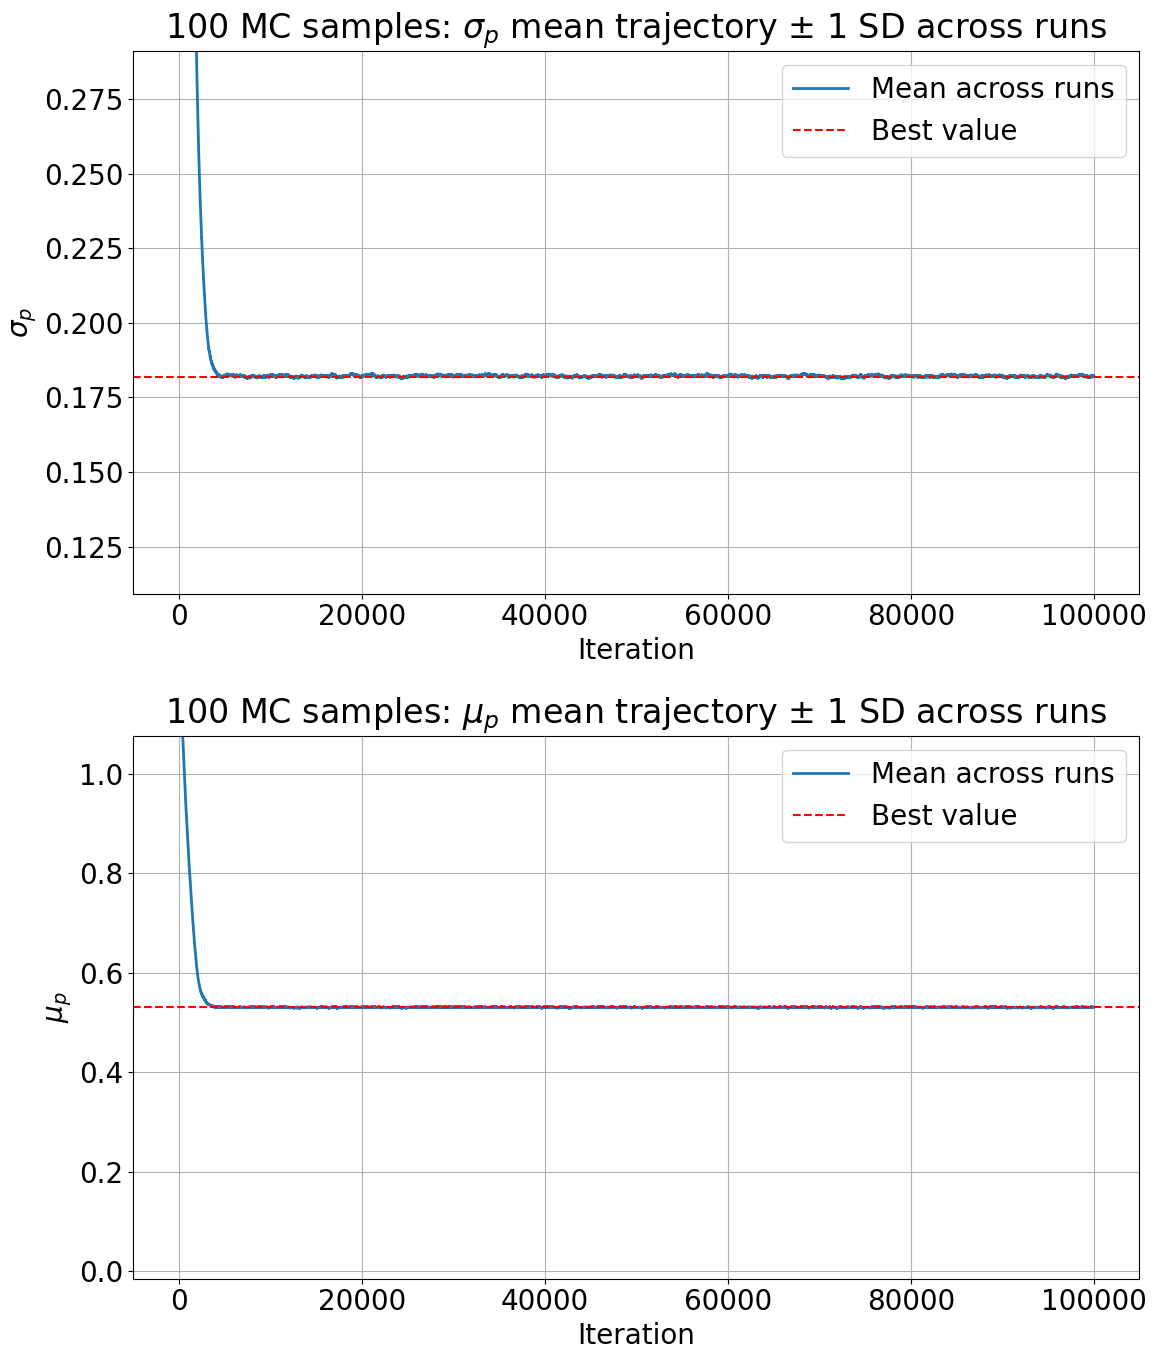

In [ ]:
# If we have "best" from config, these should be on theta-scale (0,1)
best_mu, best_std = load_best_values(
    config=config, transform=transform_fn,
    n_samples=50_000, seed=1)


plot_a_few_trajectories_1d(
    [single_means, single_stds], [multi_means, multi_stds],
    best_mu, best_std, r'$\sigma^2$')
plot_mean_band_rrs_1d(
    single_means, single_stds, best_mu, best_std,
    x, r'$\sigma^2$', 1)
plot_mean_band_rrs_1d(
    multi_means, multi_stds, best_mu, best_std,
    x, r'$\sigma^2$', 100)

# Adam results

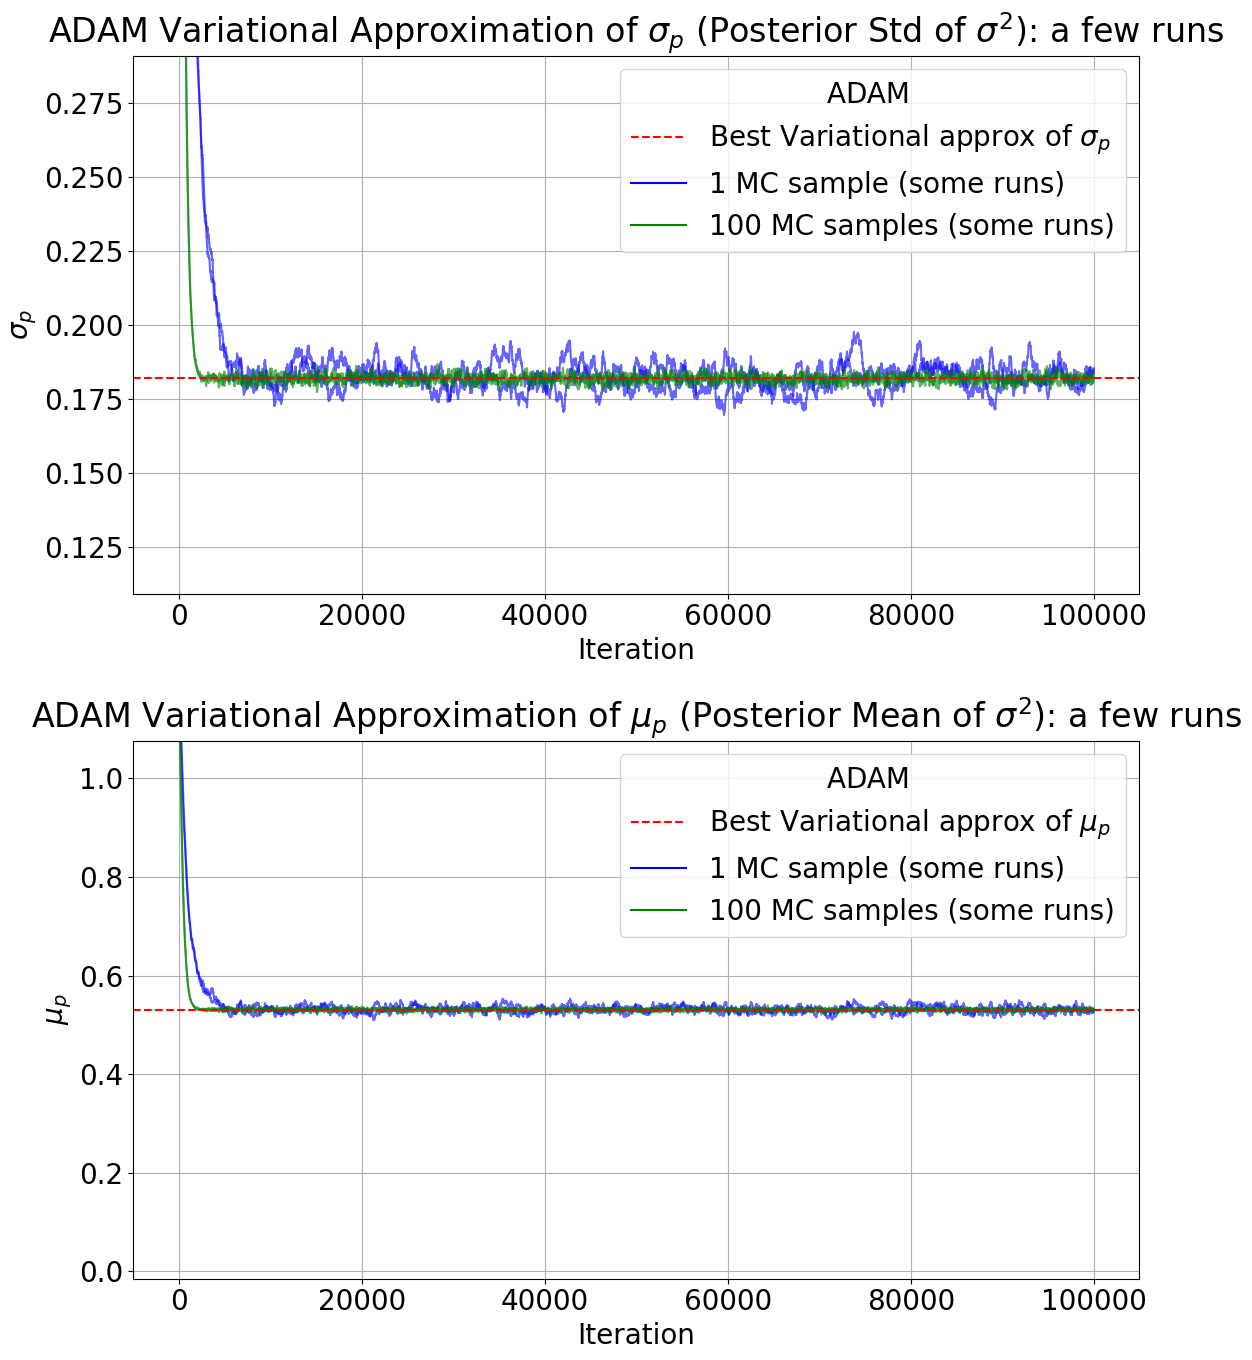

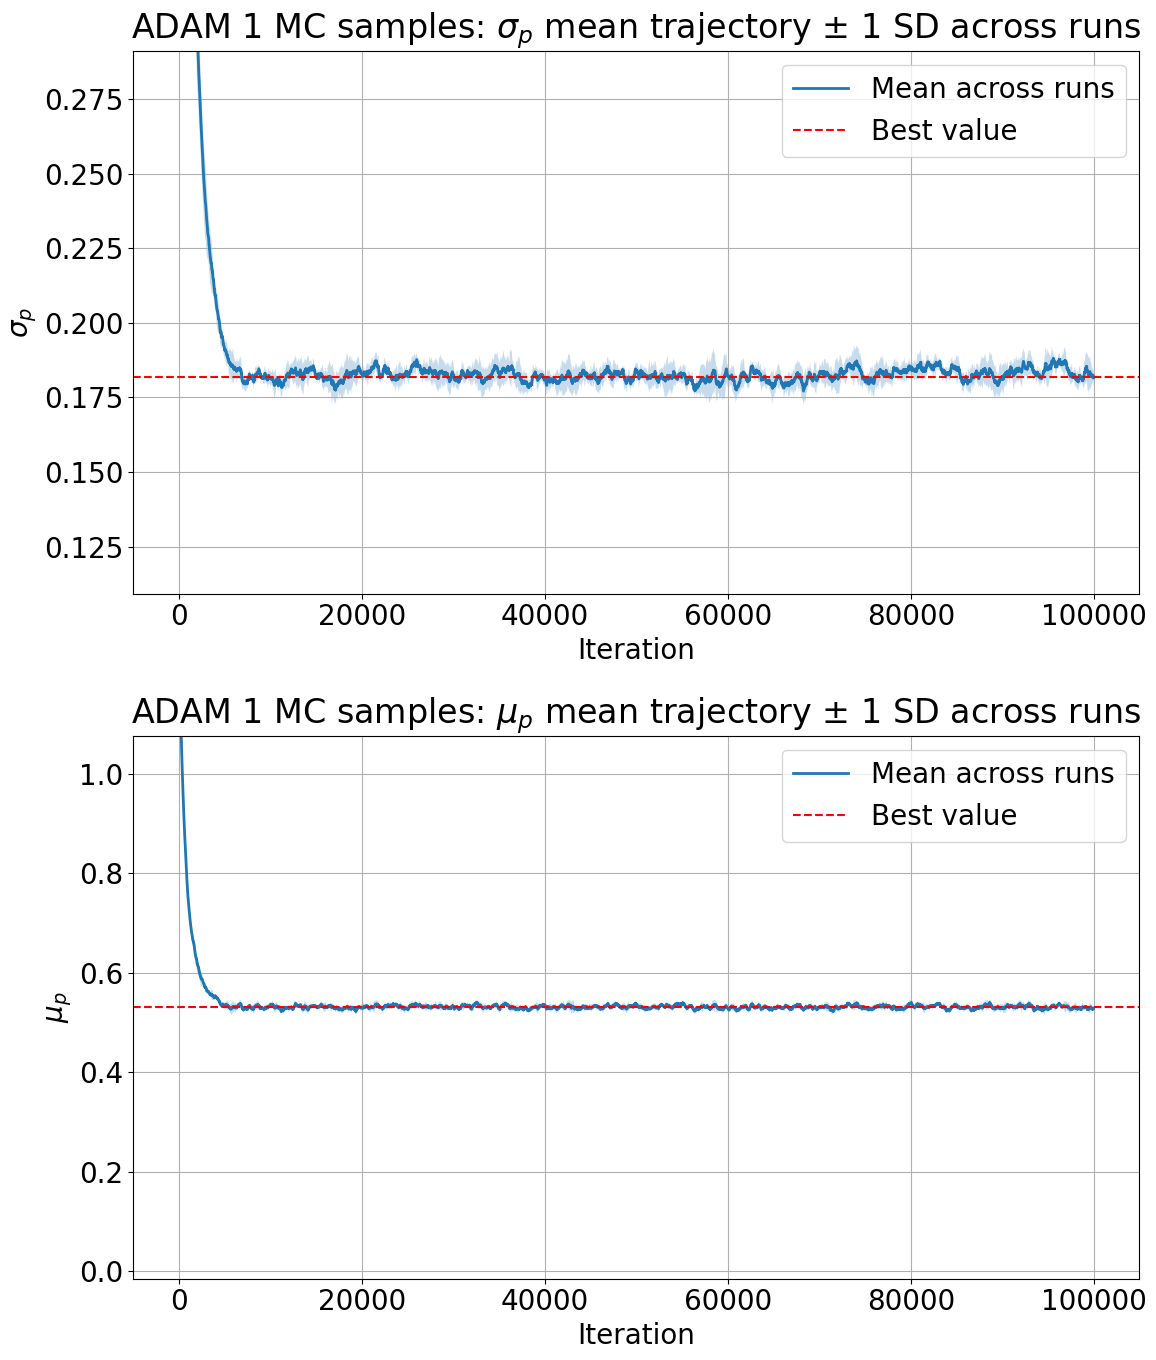

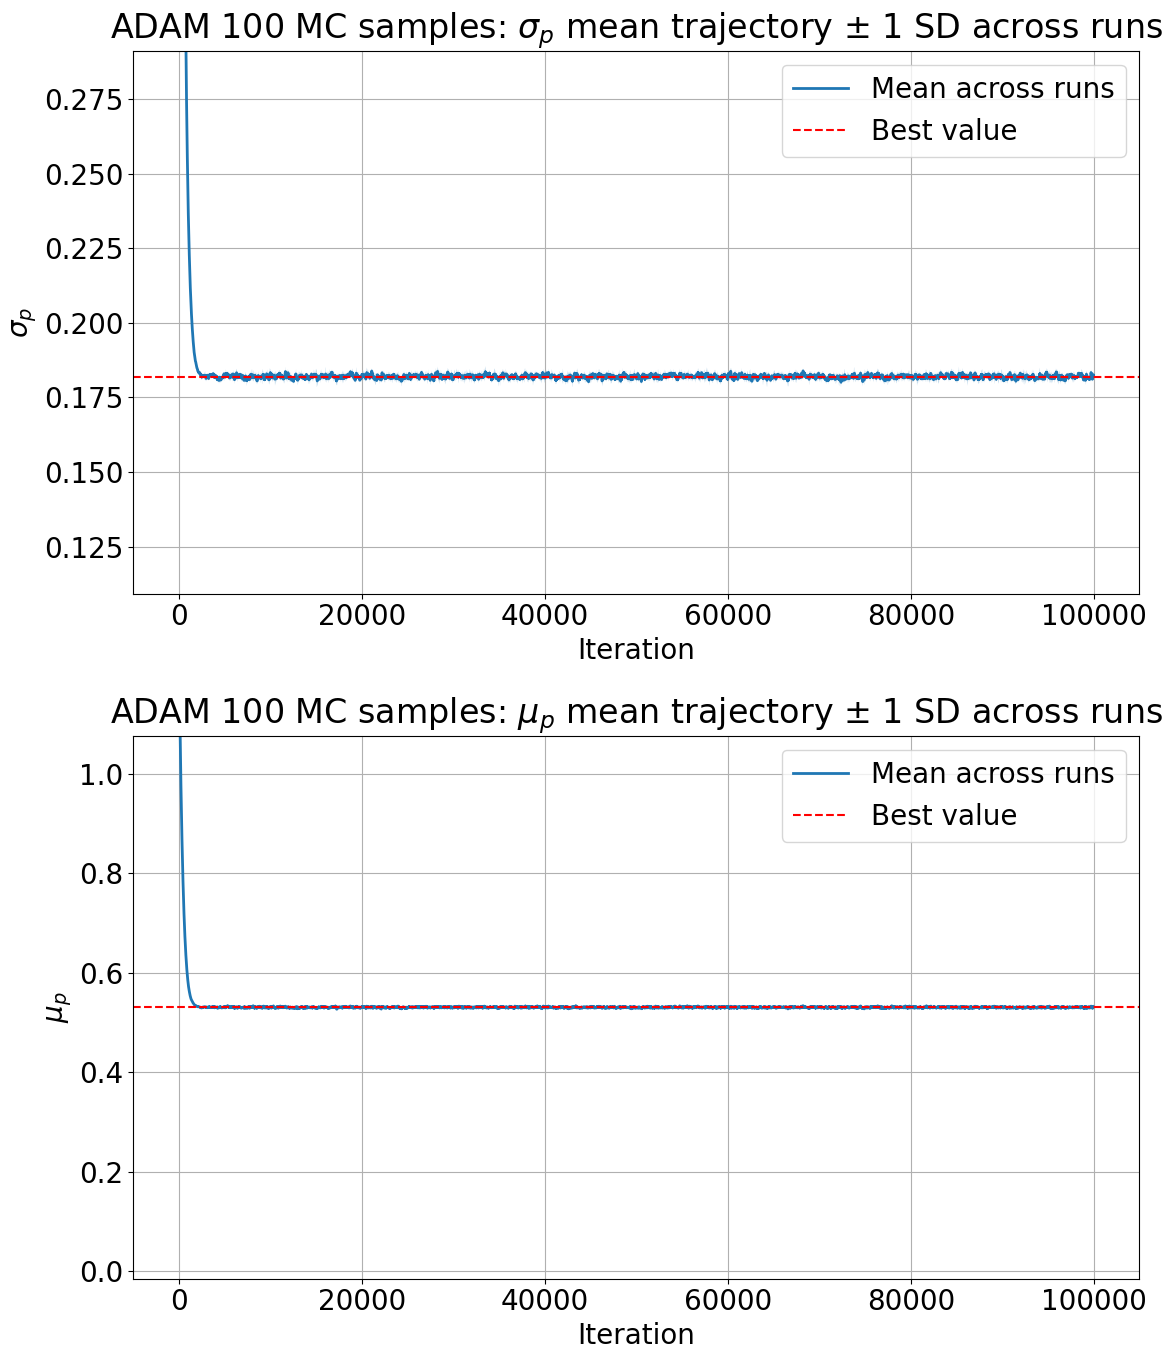

In [ ]:
plot_a_few_trajectories_1d(
    [single_means_adam, single_stds_adam], [multi_means_adam, multi_stds_adam],
    best_mu, best_std, r'$\sigma^2$', label_prefix = 'ADAM ')
plot_mean_band_rrs_1d(
    single_means_adam, single_stds_adam, best_mu, best_std,
    x, r'$\sigma^2$', 1, label_prefix='ADAM ')
plot_mean_band_rrs_1d(
    multi_means_adam, multi_stds_adam, best_mu, best_std,
    x, r'$\sigma^2$', 100, label_prefix='ADAM ')